# NASA TPV Ellipse — Boustrophedon Route Optimisation

Applies the **elliptical supercell survey model** from notebooks 01–03 to the PCA-fitted
ellipse of the real TPV PV=296 contour (from `04_nasa_data_exploration.ipynb`).

**Route**: GOOSE BAY → straight transit → boustrophedon scan → return to GOOSE BAY.
No obstacles over open ocean — all transits are straight lines.

## Budget definition

| Symbol | Meaning | Unit |
|--------|---------|------|
| **B** | Total one-way flight distance for the entire mission | **km** |

The budget must cover the full round-trip:

```
B  ≥  dist(BASE → first leg entry)  +  Σ leg lengths  +  dist(last leg exit → BASE)
```

- At **B ≈ 1 400 km** the aircraft can just reach the nearest entry point and return with zero survey.
- At **B ≈ 3 000 km** it can fly a few legs and cover ~5–10 % of the ellipse.
- At **B ≈ 12 000 km** it can fly ~50 parallel legs and cover ~95 % of the ellipse interior.

## Contrast with CCP (notebook 05)

| | CCP — contour following | Boustrophedon — interior scan |
|---|---|---|
| Scientific target | PV gradient at boundary | Ellipse interior |
| Pattern | Follow the closed contour | Parallel lawnmower legs |
| Full-coverage budget | ≈ 2 800 km | ≫ 10 000 km |


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import geopandas as gpd
import math, time, os
from math import cos, sin, sqrt, pi, radians, degrees
from dataclasses import dataclass

OUTPUT_DIR = r'C:\nasa-ffp-nurture\output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

def rot2d(a):
    c, s = cos(a), sin(a)
    return np.array([[c,-s],[s,c]])

def path_len(pts):
    return sum(np.linalg.norm(pts[i+1]-pts[i]) for i in range(len(pts)-1))

@dataclass
class EllipticalSupercell:
    center: np.ndarray; a: float; b: float; phi: float; weight: float; name: str
    def __post_init__(self):
        self.center = np.asarray(self.center, float)
        self._R = rot2d(self.phi)
    def to_world(self, e): return self.center + self._R @ np.asarray(e, float)
    def leg_halflen(self, xp, dt):
        if abs(xp) >= self.a: return None
        return self.b * sqrt(max(0., 1.-(xp/self.a)**2)) + dt
    def leg_endpoints(self, xp, dt):
        L = self.leg_halflen(xp, dt)
        if L is None: return None
        return self.to_world(np.array([xp,-L])), self.to_world(np.array([xp,L]))
    def leg_positions(self, n, s): return [-(n-1)*s/2.+i*s for i in range(n)]
    def legs_valid(self, n, s): return all(abs(xp)<self.a for xp in self.leg_positions(n,s))

def compute_coverage(cell, xps, sw, gr=2.):
    xa = np.arange(-cell.a-gr, cell.a+gr+0.1, gr)
    ya = np.arange(-cell.b-gr, cell.b+gr+0.1, gr)
    XX, YY = np.meshgrid(xa, ya)
    ins = (XX/cell.a)**2 + (YY/cell.b)**2 <= 1.
    xp = np.array(xps, float)
    dx = np.abs(XX[:,:,None] - xp[None,None,:])
    cov = (dx <= sw).sum(axis=2)
    ca = gr**2
    cv = float((ins & (cov>=1)).sum()*ca)
    ov = float((ins * np.maximum(0,cov-1)).sum()*ca)
    return cv, ov

def route_ellip_from(start, cell, n, s, dt, rev, etop):
    pos = np.asarray(start, float)
    ordered = list(reversed(cell.leg_positions(n,s))) if rev else cell.leg_positions(n,s)
    dist = 0.
    for i, xp in enumerate(ordered):
        ep = cell.leg_endpoints(xp, dt)
        if ep is None: return float('inf'), pos
        bot, top = np.asarray(ep[0],float), np.asarray(ep[1],float)
        entry, exit_ = (bot, top) if (i%2==0)!=etop else (top, bot)
        dist += np.linalg.norm(entry - pos); pos = entry
        dist += np.linalg.norm(exit_ - pos); pos = exit_
    return dist, pos

def route_ellip_wpts(start, cell, n, s, dt, rev, etop):
    pos = np.asarray(start, float)
    ordered = list(reversed(cell.leg_positions(n,s))) if rev else cell.leg_positions(n,s)
    transit_end = None; survey = []; dist = 0.
    for i, xp in enumerate(ordered):
        ep = cell.leg_endpoints(xp, dt)
        if ep is None: return float('inf'), None, None, pos
        bot, top = np.asarray(ep[0],float), np.asarray(ep[1],float)
        entry, exit_ = (bot, top) if (i%2==0)!=etop else (top, bot)
        if i == 0:
            transit_end = entry.copy()
            survey = [entry.copy()]
        else:
            survey.append(entry.copy())
        dist += np.linalg.norm(entry - pos); pos = entry
        dist += np.linalg.norm(exit_ - pos)
        survey.append(exit_.copy()); pos = exit_
    transit_wpts = np.array([np.asarray(start,float), transit_end])
    return dist, transit_wpts, np.array(survey), pos

print('Utilities loaded.')

Utilities loaded.


## 1. Data Loading and Ellipse Fit

Load the GOOSE BAY base-point and the TPV PV=296 polygon from shapefiles. Both are reprojected to WGS84, then converted to a local Cartesian frame (km) centred on the contour centroid. A PCA ellipse is fitted to the 110 contour vertices, giving the major semi-axis **a**, minor semi-axis **b**, and orientation **φ** — the same parameters used throughout the synthetic notebooks.

In [2]:
# ── Load shapefiles ───────────────────────────────────────────────────────
bp_raw   = gpd.read_file(r'C:\nasa-ffp-nurture\datasets\test_basepoint.shp').to_crs('EPSG:4326')
poly_raw = gpd.read_file(r'C:\nasa-ffp-nurture\datasets\test_polygon.shp').to_crs('EPSG:4326')

base_lonlat = np.array([bp_raw.geometry.iloc[0].x, bp_raw.geometry.iloc[0].y])
coords_ll   = np.array(poly_raw.geometry.iloc[0].coords)  # (111,2) lon/lat, closed

# ── Local Cartesian frame centred on contour centroid (km) ────────────────
lon_c = coords_ll[:-1,0].mean()
lat_c = coords_ll[:-1,1].mean()
KM_LON = 111.0 * math.cos(math.radians(lat_c))
KM_LAT = 111.0

def to_km(lon, lat):
    return np.array([(lon - lon_c)*KM_LON, (lat - lat_c)*KM_LAT])

BASE = to_km(base_lonlat[0], base_lonlat[1])
pts  = np.array([to_km(c[0],c[1]) for c in coords_ll[:-1]])  # (110,2) contour in km

# ── PCA ellipse fit (same as notebook 04) ────────────────────────────────
mean     = pts.mean(axis=0)
cov_mat  = np.cov((pts - mean).T)
eigvals, eigvecs = np.linalg.eigh(cov_mat)
order    = np.argsort(eigvals)[::-1]
eigvals, eigvecs = eigvals[order], eigvecs[:,order]

a_pca  = 2*math.sqrt(eigvals[0])   # major semi-axis (km)
b_pca  = 2*math.sqrt(eigvals[1])   # minor semi-axis (km)
phi_pca = math.atan2(eigvecs[1,0], eigvecs[0,0])  # orientation (rad)

# EllipticalSupercell centred at contour centroid (local frame origin)
cell = EllipticalSupercell(center=mean, a=a_pca, b=b_pca, phi=phi_pca, weight=1.0, name='TPV')

print(f'PCA ellipse:  a={a_pca:.1f} km  b={b_pca:.1f} km  phi={math.degrees(phi_pca):.1f} deg')
print(f'BASE (local): ({BASE[0]:.1f}, {BASE[1]:.1f}) km')
print(f'BASE → centroid: {np.linalg.norm(BASE - mean):.1f} km')

PCA ellipse:  a=320.2 km  b=179.3 km  phi=145.3 deg
BASE (local): (-693.3, 691.7) km
BASE → centroid: 979.4 km


## 2. Survey Configuration Precomputation

Enumerate all feasible boustrophedon configurations: number of legs **n** ∈ {1…30}, leg spacing **s**, reversal flag, and entry-side flag. For each configuration:
- Compute the **coverage fraction** — fraction of the ellipse interior swept by at least one 12 km strip (plus 0.5× overlap bonus), evaluated on a 2 km grid.
- Compute the **total round-trip distance**: transit from GOOSE BAY to the first leg entry, all boustrophedon legs, then return from the last leg exit to GOOSE BAY.

The result is a list of ~900 configs used by all subsequent budget analyses.

In [3]:
# ── Precompute all survey configurations ──────────────────────────────────
# Each config: (n legs, spacing s, rev, etop) → score, total round-trip distance
#
# Total route = BASE → [transit] → leg_1_entry → boustrophedon → leg_n_exit → [return] → BASE
# total_dist  = route_ellip_from(BASE, ...) + norm(exit_pt - BASE)

SW = 12.; DT = 8.; S_MIN = 18.; N_MAX = 30; N_S_STEPS = 8; OVERLAP_BONUS = 0.5
ELLIP_AREA = pi * cell.a * cell.b

print('Precomputing survey configurations...')
t0 = time.time()
configs = []
for n in range(1, N_MAX+1):
    if n == 1:
        sl = [0.]
    else:
        s_max = 2.*cell.a/(n-1)*0.999
        sl = [] if s_max < S_MIN else list(np.linspace(S_MIN, s_max, N_S_STEPS))
    for s in sl:
        if not cell.legs_valid(n, s): continue
        xps = cell.leg_positions(n, s)
        cv, ov = compute_coverage(cell, xps, SW)
        score = (cv + OVERLAP_BONUS*ov) / ELLIP_AREA
        for rev in [False, True]:
            for etop in [False, True]:
                d_survey, exit_pt = route_ellip_from(BASE, cell, n, s, DT, rev, etop)
                d_return = float(np.linalg.norm(np.asarray(exit_pt) - BASE))
                configs.append(dict(
                    n=n, s=float(s), rev=rev, etop=etop,
                    score=score, total_dist=d_survey+d_return, exit_pt=np.asarray(exit_pt)
                ))

print(f'Done: {len(configs)} configs in {time.time()-t0:.1f}s')

# Best config per (n) for quick inspection
print(f'\n{"n":>4}  {"best score":>12}  {"total dist (km)":>16}')
print('-'*36)
for n in range(1, N_MAX+1):
    sub = [c for c in configs if c['n']==n]
    if not sub: continue
    best = max(sub, key=lambda c: c['score'])
    print(f'{n:>4}  {best["score"]:>12.4f}  {best["total_dist"]:>16.1f}')

Precomputing survey configurations...


Done: 932 configs in 2.1s

   n    best score   total dist (km)
------------------------------------
   1        0.0477            2367.7
   2        0.0941            2773.6
   3        0.1413            3228.8
   4        0.1882            3545.1
   5        0.2349            3996.5
   6        0.2814            4308.6
   7        0.3275            4756.1
   8        0.3736            5063.4
   9        0.4189            5506.1
  10        0.4641            5807.9
  11        0.5088            6244.5
  12        0.5510            6540.0
  13        0.5869            6969.4
  14        0.6271            7222.3
  15        0.6693            7632.5
  16        0.7104            7906.0
  17        0.7506            8306.5
  18        0.7849            8572.1
  19        0.8135            8961.7
  20        0.8483            9116.2
  21        0.8857            9484.3
  22        0.9102            9730.6
  23        0.9349           10086.1
  24        0.9612           10186.7
  25       

## 3. Budget Analysis

For each flight budget B (km), select the configuration from the precomputed list that maximises coverage while staying within budget. Two plots are produced:
- **Left**: coverage fraction (%) as a function of B — shows how much of the TPV interior can be scanned for a given range.
- **Right**: optimal number of legs as a function of B — shows how the solver trades leg count against transit cost.

  Budget    Coverage   Best n    Actual dist
---------------------------------------------
    3000        9.4%        2       2773.6 km
    5000       32.8%        7       4744.8 km
    8000       71.0%       16       7906.0 km
   11000      102.4%       28      10991.1 km


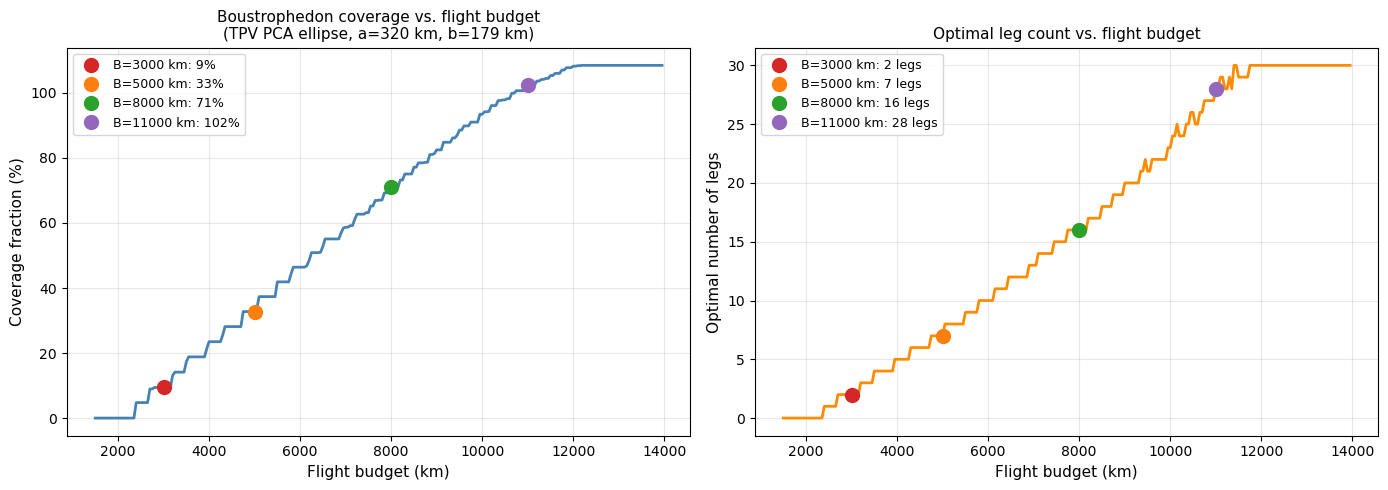

Saved → C:\nasa-ffp-nurture\output\fig8_ellipse_coverage_vs_budget.png


In [4]:
# ── Budget analysis ───────────────────────────────────────────────────────
budgets = np.arange(1500, 14000, 50)
best_score, best_n, best_dist = [], [], []
for B in budgets:
    feas = [c for c in configs if c['total_dist'] <= B]
    if feas:
        b = max(feas, key=lambda c: (c['score'], -c['total_dist']))
        best_score.append(b['score']*100)
        best_n.append(b['n'])
        best_dist.append(b['total_dist'])
    else:
        best_score.append(0.)
        best_n.append(0)
        best_dist.append(0.)

best_score = np.array(best_score)
best_n     = np.array(best_n, int)

key_budgets = [3000, 5000, 8000, 11000]

print(f'{"Budget":>8}  {"Coverage":>10}  {"Best n":>7}  {"Actual dist":>13}')
print('-'*45)
for B in key_budgets:
    feas = [c for c in configs if c['total_dist'] <= B]
    if feas:
        b = max(feas, key=lambda c: (c['score'], -c['total_dist']))
        print(f'{B:>8}  {b["score"]*100:>9.1f}%  {b["n"]:>7}  {b["total_dist"]:>11.1f} km')
    else:
        print(f'{B:>8}  {"unreachable":>10}')

# ── Figure: coverage fraction vs budget ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(budgets, best_score, '-', color='steelblue', lw=2)
for B, col in zip(key_budgets, ['#d62728','#ff7f0e','#2ca02c','#9467bd']):
    idx = np.argmin(np.abs(budgets - B))
    ax.plot(B, best_score[idx], 'o', color=col, ms=10, zorder=5,
            label=f'B={B} km: {best_score[idx]:.0f}%')
ax.set_xlabel('Flight budget (km)', fontsize=11)
ax.set_ylabel('Coverage fraction (%)', fontsize=11)
ax.set_title('Boustrophedon coverage vs. flight budget\n(TPV PCA ellipse, a=320 km, b=179 km)', fontsize=11)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(budgets, best_n, '-', color='darkorange', lw=2)
for B, col in zip(key_budgets, ['#d62728','#ff7f0e','#2ca02c','#9467bd']):
    idx = np.argmin(np.abs(budgets - B))
    ax.plot(B, best_n[idx], 'o', color=col, ms=10, zorder=5,
            label=f'B={B} km: {best_n[idx]} legs')
ax.set_xlabel('Flight budget (km)', fontsize=11)
ax.set_ylabel('Optimal number of legs', fontsize=11)
ax.set_title('Optimal leg count vs. flight budget', fontsize=11)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
out = os.path.join(OUTPUT_DIR, 'fig8_ellipse_coverage_vs_budget.png')
plt.savefig(out, dpi=130, bbox_inches='tight')
plt.show()
plt.close()
print(f'Saved → {out}')

## 4. Route Visualisation

Draw the full flight path at three representative budgets (3 000 km, 5 000 km, 8 000 km). Each panel shows:
- The real PV=296 contour (blue fill)
- The PCA-fitted ellipse (orange dashes)
- The boustrophedon survey legs (coloured solid line)
- The straight-line transit from GOOSE BAY to the survey entry point, and back from the exit point (grey dashes)

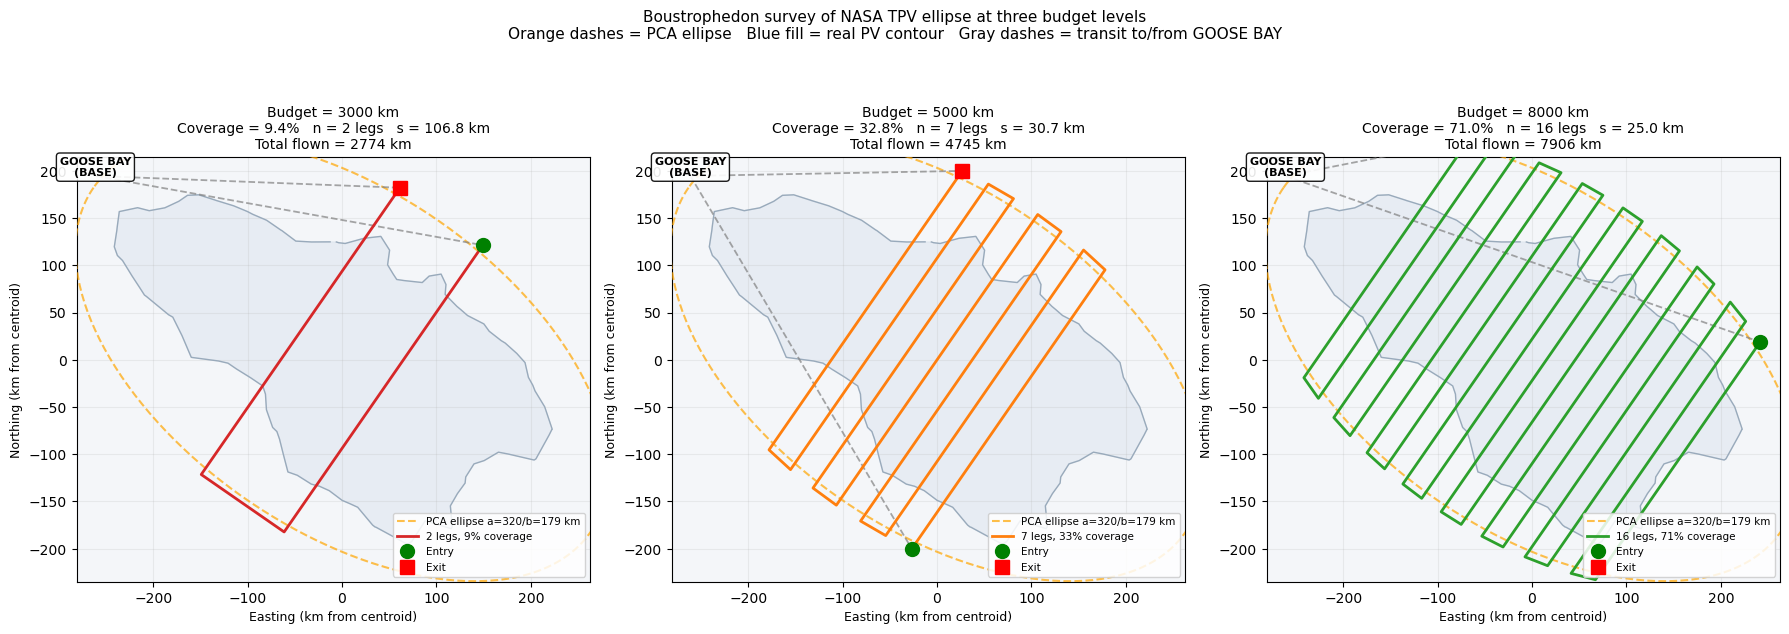

Saved → C:\nasa-ffp-nurture\output\fig9_ellipse_routes.png


In [5]:
# ── Route visualisation at 3 budget levels ────────────────────────────────
PLOT_BUDGETS = [3000, 5000, 8000]
PALETTE      = ['#d62728', '#ff7f0e', '#2ca02c']

th = np.linspace(0, 2*pi, 300)
R  = np.array([[cos(phi_pca),-sin(phi_pca)],[sin(phi_pca),cos(phi_pca)]])
ell_pts = (R @ np.vstack([a_pca*np.cos(th), b_pca*np.sin(th)])).T + mean

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for ax, B, col in zip(axes, PLOT_BUDGETS, PALETTE):
    feas = [c for c in configs if c['total_dist'] <= B]
    best = max(feas, key=lambda c: (c['score'], -c['total_dist']))
    n_, s_ = best['n'], best['s']
    _, tr_wpts, surv_wpts, exit_pt = route_ellip_wpts(
        BASE, cell, n_, s_, DT, best['rev'], best['etop'])
    pct = best['score'] * 100

    ax.set_facecolor('#f4f6f9')
    ax.fill(pts[:,0], pts[:,1], color='#d0dce8', alpha=0.35, zorder=1)
    ax.plot(pts[:,0], pts[:,1], color='#99aabb', lw=1, zorder=2)
    ax.plot(ell_pts[:,0], ell_pts[:,1], '--', color='orange', lw=1.5,
            alpha=0.7, zorder=3, label=f'PCA ellipse a={a_pca:.0f}/b={b_pca:.0f} km')
    ax.plot(surv_wpts[:,0], surv_wpts[:,1], '-', color=col, lw=2, zorder=4,
            label=f'{n_} legs, {pct:.0f}% coverage')
    ax.plot(*tr_wpts[-1], 'o', color='green', ms=10, zorder=6, label='Entry')
    ax.plot(*exit_pt,     's', color='red',   ms=10, zorder=6, label='Exit')

    xlim = [pts[:,0].min()-40, pts[:,0].max()+40]
    ylim = [pts[:,1].min()-40, pts[:,1].max()+40]
    bx = np.clip(BASE[0], xlim[0]+20, xlim[1]-20)
    by = np.clip(BASE[1], ylim[0]+20, ylim[1]-20)
    ax.annotate('GOOSE BAY\n(BASE)', xy=(bx,by), fontsize=8,
                color='black', fontweight='bold', ha='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9), zorder=7)
    for pt in [tr_wpts[-1], exit_pt]:
        ax.plot([bx,pt[0]], [by,pt[1]], '--', color='gray', lw=1.3, alpha=0.7, zorder=3)

    ax.set_xlim(xlim); ax.set_ylim(ylim); ax.set_aspect('equal')
    ax.set_xlabel('Easting (km from centroid)', fontsize=9)
    ax.set_ylabel('Northing (km from centroid)', fontsize=9)
    ax.set_title(
        f'Budget = {B} km\n'
        f'Coverage = {pct:.1f}%   n = {n_} legs   s = {s_:.1f} km\n'
        f'Total flown = {best["total_dist"]:.0f} km', fontsize=10)
    ax.legend(fontsize=7.5, loc='lower right', framealpha=0.85)
    ax.grid(True, alpha=0.2)

plt.suptitle(
    'Boustrophedon survey of NASA TPV ellipse at three budget levels\n'
    'Orange dashes = PCA ellipse   Blue fill = real PV contour   '
    'Gray dashes = transit to/from GOOSE BAY',
    fontsize=11)
plt.tight_layout()
out = os.path.join(OUTPUT_DIR, 'fig9_ellipse_routes.png')
plt.savefig(out, dpi=130, bbox_inches='tight')
plt.show()
plt.close()
print(f'Saved → {out}')

## 5. Summary Table

Tabulate the best achievable coverage and configuration for flight budgets from 2 500 km to 12 000 km. The final note compares boustrophedon interior scanning against contour-following (notebook 05) to highlight the cost difference between the two scientific objectives.

In [6]:
# ── Summary ───────────────────────────────────────────────────────────────
print('='*65)
print('BOUSTROPHEDON SURVEY — NASA TPV ELLIPSE SUMMARY')
print('='*65)
print(f'Ellipse:  a={a_pca:.1f} km  b={b_pca:.1f} km  area={ELLIP_AREA:.0f} km2')
print(f'BASE (GOOSE BAY) → centroid: {np.linalg.norm(BASE-mean):.1f} km')
print(f'Strip width SW={SW} km   leg extension DT={DT} km')
print()
print(f'{"Budget":>8}  {"Coverage":>10}  {"n legs":>7}  {"spacing":>9}  {"Total dist":>12}')
print('-'*55)
for B in [2500, 3000, 4000, 5000, 6000, 8000, 10000, 12000]:
    feas = [c for c in configs if c['total_dist'] <= B]
    if not feas:
        print(f'{B:>8}  {"(unreachable)":>10}')
        continue
    b = max(feas, key=lambda c: (c['score'], -c['total_dist']))
    print(f'{B:>8}  {b["score"]*100:>9.1f}%  {b["n"]:>7}  {b["s"]:>8.1f} km  {b["total_dist"]:>10.1f} km')
print()
print('Key insight: the TPV is ~320 km wide — full interior coverage requires')
print('~53 legs x ~360 km each >> 10,000 km survey distance + 1,400 km transit.')
print('Contour-following (notebook 05) achieves full boundary coverage at ~2,800 km.')

BOUSTROPHEDON SURVEY — NASA TPV ELLIPSE SUMMARY
Ellipse:  a=320.2 km  b=179.3 km  area=180300 km2
BASE (GOOSE BAY) → centroid: 979.4 km
Strip width SW=12.0 km   leg extension DT=8.0 km

  Budget    Coverage   n legs    spacing    Total dist
-------------------------------------------------------
    2500        4.8%        1       0.0 km      2367.7 km
    3000        9.4%        2     106.8 km      2773.6 km
    4000       23.5%        5      38.3 km      3987.0 km
    5000       32.8%        7      30.7 km      4744.8 km
    6000       46.4%       10      25.6 km      5807.9 km
    8000       71.0%       16      25.0 km      7906.0 km
   10000       93.4%       23      24.3 km      9924.1 km
   12000      108.2%       30      19.7 km     11952.4 km

Key insight: the TPV is ~320 km wide — full interior coverage requires
~53 legs x ~360 km each >> 10,000 km survey distance + 1,400 km transit.
Contour-following (notebook 05) achieves full boundary coverage at ~2,800 km.
